In [66]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout, edwards, codebench, cs1eng

# Select a dataset by setting the config variable
config = cs1eng.S24

datasets_dir = os.path.join('..', '..', '..', 'sample_data')
dataset_paths = {
    # Edwards 2019 datasets is split into two semesters
    'edwards_f19': os.path.join(datasets_dir, 'edwards', '2019'),
    'edwards_s19': os.path.join(datasets_dir, 'edwards', '2019'),
}

if config.name in dataset_paths:
    dataset_root_dir = dataset_paths[config.name]
else:
    # Most datasets follow a simple naming convention
    dataset_name, dataset_semester = config.name.split('_')
    dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)

dataset = config.load(dataset_root_dir)

In [68]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [69]:
# TODO: Replace this with config files!

# from progsnap2.analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
# from progsnap2.analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
# from progsnap2.analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
# from progsnap2.analytics.ps2_dataset import SortPreprocessor, FilterPreprocessor
# from progsnap2.spec.enums import EventType

# data_config_path = None
# problem_id_col = None
# timestamp_col = None
# idle_gap = None
# break_gap = None
# main_table_preprocessors = []
# link_table_preprocessors = []
# submit_event = EventType.Submit
# grades_link_table = "Subject"
# grades_col = None
# start_time = None
# end_time = None
# early_percentage = None
# assignment_ids = None
# compile_error_type_column = Cols.CompileMessageType
# compile_event = EventType.Compile
# compile_error_event = EventType.CompileError
# output_suffix = ''

# falconcode_f21_config = {
#     "config_path": "sample_data_configs/falconcode.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         FilterPreprocessor(Cols.TermID, "Fall 2021"),
#     ],
#     "early_percentage": 0.25,
# }

# # Note: Only Fall has compilation data; spring has no Run.Program events!
# edwards_s19_config = {
#     "config_path": "sample_data_configs/edwards2019.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#         # Make sure this comes last so Fall is correct
#         ClassSubsetPreprocessor("Spring"),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2019-02-25 00:00:00",
#     "early_percentage": 0.23,
#     "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
#     "grades_col": "exam2",
#     "output_suffix": "-s19",
# }

# edwards_f19_config = edwards_s19_config.copy()
# edwards_f19_config["mt_preprocessing_steps"] = edwards_s19_config["mt_preprocessing_steps"].copy()
# edwards_f19_config["mt_preprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
# edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
# edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
# edwards_f19_config["early_percentage"] = 0.42
# edwards_f19_config["output_suffix"] = "-f19"

# edwards2021_config = {
#     "config_path": "sample_data_configs/edwards2021.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2022-01-01 00:00:00",
#     "early_percentage": 0.4,
#     "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
#     "grades_col": "FinalScore",
# }

# cwo_s19_config = {
#     "config_path": "sample_data_configs/cwo_s19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.33,
# }

# cwo_f19_config = {
#     "config_path": "sample_data_configs/cwo_f19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.25,
# }

# codebench2024_config = {
#     "config_path": "sample_data_configs/codebench2024.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
#     "mt_preprocessing_steps": [
#         CodeBenchAddParentEventIDs(),
#     ],
#     "grades_link_table": "CourseSubject",
#     "grades_col": "final-grade",
#     "start_time": "2024-09-01 00:00:00",
#     "early_percentage": 0.28,
#     "compile_error_type_col": "ProgramErrorOutput",
#     "compile_event": EventType.Submit,
#     "compile_error_event": EventType.RunTest,
# }

# # config = cwo_f19_config
# # config = cwo_s19_config
# # config = codebench2024_config
# # config = edwards2021_config
# # config = edwards_s19_config
# # config = edwards_f19_config
# config = falconcode_f21_config
# locals().update(config)

In [70]:
main_table = dataset.get_main_table()
main_table.head()

,EventID,SubjectID,ProblemID,EventType,CodeStateID,ClientTimestamp,ServerTimestamp,Score
0,6286,Papaya,inlab2,FileEdit,5508,2024-01-17 18:59:34,2024-01-17 18:59:34,NaN
1,6292,Papaya,inlab2,Submit,5508,2024-01-17 18:59:34,2024-01-17 18:59:35,0.166667
2,6348,Raspberry,inlab2,FileEdit,5508,2024-01-17 18:59:51,2024-01-17 18:59:54,NaN
3,6350,Raspberry,inlab2,Submit,5508,2024-01-17 18:59:51,2024-01-17 18:59:55,0.166667
4,6351,Strawberry,inlab2,FileEdit,5554,2024-01-17 19:00:09,2024-01-17 18:59:55,NaN


In [88]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

In [89]:
# Used for converting percentages to raw early time when
# creating a dataset config; not needed when using existing configs
min = main_table[timestamp_col].min()
max = main_table[timestamp_col].max()
min + (max - min) * 0.29

Timestamp('2024-02-11 11:58:25.179999999')

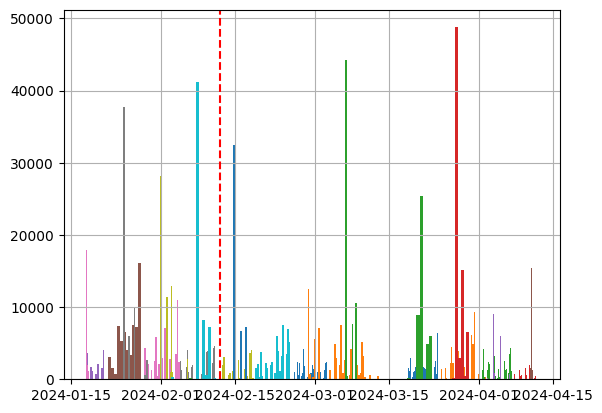

In [94]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
early_timestamp = pd.to_datetime(config.early_time)
if early_timestamp is None:
    print("Warning: No early time cutoff specified")
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
    if early_timestamp is not None:
        plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        if early_timestamp is not None:
            plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
        plt.show()

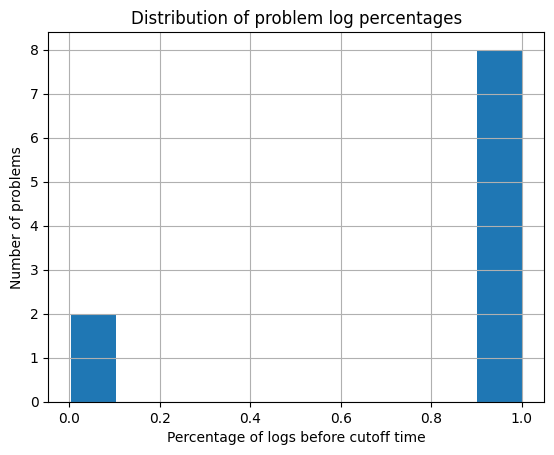

Removing partial problems: Index(['homework6', 'inlab11'], dtype='object', name='ProblemID')
This removed 0.15% of data
Semester start 2024-01-17 18:59:34
Semester end 2024-04-11 23:45:16
Early cutoff time 2024-02-12 00:00:00
Early Problem IDs: ['inlab2' 'homework2' 'homework3' 'inlab3' 'homework4' 'inlab4' 'inlab5'
 'homework5']
Total number of rows: 442562
Percent of logs:  35.99062829613738
Problems: 8 / 23


In [95]:
from progsnap2.analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [96]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>]

In [97]:
from progsnap2.analytics.metrics.errors import ErrorMetrics

error_results = None

error_metrics = ErrorMetrics(True,
                             compile_message_type_column=config.compile_error_type_column,
                             compile_event=config.compile_event,
                             compile_error_event=config.compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

KeyError: <MainTableColumns.ParentEventID: 'ParentEventID'>

In [158]:
# Distribution of each error metric across students/problems
error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,3870.000000,3870.000000,8053.000000
mean,0.826326,1.486584,3.840929
std,0.123182,4.792404,8.031044
min,0.727273,0.000000,0.000000
25%,0.727273,0.000000,1.000000
50%,0.727273,0.000000,1.000000
75%,1.000000,1.333333,4.000000
max,1.000000,109.359419,212.000000


In [159]:
# Correlate the metrics
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.837743,-0.069699
RepeatedErrorDensity,0.837743,1.000000,0.188197
FailedCompileCount,-0.069699,0.188197,1.000000


<Axes: ylabel='Frequency'>

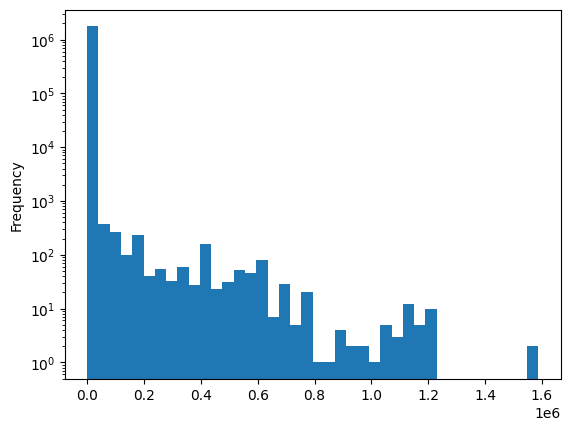

In [160]:
from progsnap2.analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [161]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [162]:
from progsnap2.analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

C:\Users\twprice\AppData\Local\Temp\ipykernel_7532\1574692767.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  \
SubjectID  AssignmentID ProblemID    CourseID                               
13108823   4.592827e+08 1.076448e+09 218908526.0     279.926      161.617   
28270295   2.408150e+08 1.076448e+09 218908526.0       0.000        0.000   
           2.909834e+08 7.049834e+08 218908526.0       0.000        0.000   
                        7.758383e+08 218908526.0       0.000        0.000   
                        1.078076e+09 218908526.0       0.000        0.000   
...                                                      ...          ...   
4275215466 1.538637e+09 1.417621e+09 218908526.0     152.585       76.344   
                        2.249046e+09 218908526.0     361.852      174.451   
                        3.900747e+09 218908526.0     154.119        0.000   
           2.455319e+09 2.546841e+08 218908526.0     171.571      154.387   
                        3.974738e+09 218908526.0      59.602        0.000   

                                                  TotalTime  \
SubjectID  AssignmentID ProblemID    CourseID                 
13108823   4.592827e+08 1.076448e+09 218908526.0    441.543   
28270295   2.408150e+08 1.076448e+09 218908526.0      0.000   
           2.909834e+08 7.049834e+08 218908526.0      0.000   
                        7.758383e+08 218908526.0      0.000   
                        1.078076e+09 218908526.0      0.000   
...                                                     ...   
4275215466 1.538637e+09 1.417621e+09 218908526.0    228.929   
                        2.249046e+09 218908526.0    536.303   
                        3.900747e+09 218908526.0    154.119   
           2.455319e+09 2.546841e+08 218908526.0    325.958   
                        3.974738e+09 218908526.0     59.602   

                                                  ActiveTimeAfterCorrect  \
SubjectID  AssignmentID ProblemID    CourseID                              
13108823   4.592827e+08 1.076448e+09 218908526.0                   0.000   
28270295   2.408150e+08 1.076448e+09 218908526.0                   0.000   
           2.909834e+08 7.049834e+08 218908526.0                   0.000   
                        7.758383e+08 218908526.0                   0.000   
                        1.078076e+09 218908526.0                   0.000   
...                                                                  ...   
4275215466 1.538637e+09 1.417621e+09 218908526.0                   7.348   
                        2.249046e+09 218908526.0                   0.000   
                        3.900747e+09 218908526.0                   0.000   
           2.455319e+09 2.546841e+08 218908526.0                   0.000   
                        3.974738e+09 218908526.0                   0.000   

                                                  #Breaks  \
SubjectID  AssignmentID ProblemID    CourseID               
13108823   4.592827e+08 1.076448e+09 218908526.0        0   
28270295   2.408150e+08 1.076448e+09 218908526.0        0   
           2.909834e+08 7.049834e+08 218908526.0        0   
                        7.758383e+08 218908526.0        0   
                        1.078076e+09 218908526.0        0   
...                                                   ...   
4275215466 1.538637e+09 1.417621e+09 218908526.0        0   
                        2.249046e+09 218908526.0        2   
                        3.900747e+09 218908526.0        0   
           2.455319e+09 2.546841e+08 218908526.0        0   
                        3.974738e+09 218908526.0        1   

                                                               StartTime  \
SubjectID  AssignmentID ProblemID    CourseID                              
13108823   4.592827e+08 1.076448e+09 218908526.0 2024-09-14 00:57:47.067   
28270295   2.408150e+08 1.076448e+09 218908526.0 2024-09-04 18:24:28.910   
           2.909834e+08 7.049834e+08 218908526.0 2024-09-02 18:19:14.760   
                        7.758383e+08 218908526.0 2024-09-04 19:00

In [163]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,8.053000e+03,8053.000000,8053.000000,8053.000000,8053.000000,8053,7190,8053
mean,2.927335e+02,173.778285,466.511781,9.903354,0.661989,2024-09-13 04:23:28.588503040,2024-09-13 01:49:41.524016640,2024-09-13 20:39:12.446660352
min,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,2024-09-01 03:52:26.560000
25%,9.900000e-01,0.000000,27.060000,0.000000,0.000000,2024-09-05 14:06:37.060000,2024-09-05 01:05:44.987500032,2024-09-08 17:43:09.870000128
50%,1.731140e+02,60.758000,246.112000,0.000000,0.000000,2024-09-11 22:16:13.798000128,2024-09-11 19:26:09.234999808,2024-09-12 17:52:57.910000128
75%,4.037910e+02,221.746000,617.174000,0.000000,1.000000,2024-09-18 18:48:08.063000064,2024-09-18 18:59:01.807500032,2024-09-19 00:33:37.560000
max,6.947802e+03,6630.387000,13578.189000,1511.286000,51.000000,2024-09-27 23:30:48.935000,2024-09-27 23:27:23.930000,2024-09-27 23:59:59.997000
std,4.193758e+02,308.362001,686.687108,55.870472,1.550921,NaN,NaN,NaN


In [164]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.729872,0.953527,0.124973,0.445131,0.599996,0.501624,0.611583
PassiveTime,0.729872,1.000000,0.883502,0.130739,0.510912,0.336513,0.264307,0.369059
TotalTime,0.953527,0.883502,1.000000,0.135454,0.499657,0.535582,0.441934,0.555455
ActiveTimeAfterCorrect,0.124973,0.130739,0.135454,1.000000,0.073452,0.033342,0.151110,0.112175
#Breaks,0.445131,0.510912,0.499657,0.073452,1.000000,0.133796,0.078148,0.208735
StartTime,0.599996,0.336513,0.535582,0.033342,0.133796,1.000000,0.700512,0.965215
FirstCorrectTime,0.501624,0.264307,0.441934,0.151110,0.078148,0.700512,1.000000,0.695302
EndTime,0.611583,0.369059,0.555455,0.112175,0.208735,0.965215,0.695302,1.000000


In [165]:
from progsnap2.analytics.metrics.score import SubmissionScoreMetrics
from progsnap2.spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_7532\3695921909.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [166]:
subject_problem_score.head()

Attempts  FirstCorrect  \
SubjectID AssignmentID ProblemID    CourseID                              
13108823  459282688.0  1.076448e+09 218908526.0         3         False   
28270295  240815043.0  1.076448e+09 218908526.0         1          True   
          290983374.0  7.049834e+08 218908526.0         1          True   
                       7.758383e+08 218908526.0         1          True   
                       1.078076e+09 218908526.0         1          True   

                                                 EverCorrect  Attempted  \
SubjectID AssignmentID ProblemID    CourseID                              
13108823  459282688.0  1.076448e+09 218908526.0        False       True   
28270295  240815043.0  1.076448e+09 218908526.0         True       True   
          290983374.0  7.049834e+08 218908526.0         True       True   
                       7.758383e+08 218908526.0         True       True   
                       1.078076e+09 218908526.0         True       True   

                                                 MaxScore  MinScore  \
SubjectID AssignmentID ProblemID    CourseID                          
13108823  459282688.0  1.076448e+09 218908526.0       0.0       0.0   
28270295  240815043.0  1.076448e+09 218908526.0       1.0       1.0   
          290983374.0  7.049834e+08 218908526.0       1.0       1.0   
                       7.758383e+08 218908526.0       1.0       1.0   
                       1.078076e+09 218908526.0       1.0       1.0   

                                                 MeanScore  TotalAttempts  
SubjectID AssignmentID ProblemID    CourseID                               
13108823  459282688.0  1.076448e+09 218908526.0        0.0              3  
28270295  240815043.0  1.076448e+09 218908526.0        1.0              1  
          290983374.0  7.049834e+08 218908526.0        1.0              1  
                       7.758383e+08 218908526.0        1.0              1  
                       1.078076e+09 218908526.0        1.0              1

In [167]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,8053.000000,8053.000000,8053.000000,8053.000000,8053.000000
mean,3.520303,0.895608,0.532928,0.647393,3.840929
std,7.748018,0.303750,0.488436,0.394726,8.031044
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.250000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,1.000000,1.000000,1.000000,4.000000
max,212.000000,1.000000,1.000000,1.000000,212.000000


In [168]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,AssignmentID,ProblemID,CourseID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,13108823,459282688.0,1.076448e+09,218908526.0,279.926,161.617,441.543,0.0,0,2024-09-14 00:57:47.067,...,False,False,True,0.0,0.0,0.0,3,0.863636,0.5,3.0
1,28270295,240815043.0,1.076448e+09,218908526.0,0.000,0.000,0.000,0.0,0,2024-09-04 18:24:28.910,...,True,True,True,1.0,1.0,1.0,1,NaN,NaN,1.0
2,28270295,290983374.0,7.049834e+08,218908526.0,0.000,0.000,0.000,0.0,0,2024-09-02 18:19:14.760,...,True,True,True,1.0,1.0,1.0,1,NaN,NaN,1.0
3,28270295,290983374.0,7.758383e+08,218908526.0,0.000,0.000,0.000,0.0,0,2024-09-04 19:00:45.720,...,True,True,True,1.0,1.0,1.0,1,NaN,NaN,1.0
4,28270295,290983374.0,1.078076e+09,218908526.0,0.000,0.000,0.000,0.0,0,2024-09-04 18:53:21.230,...,True,True,True,1.0,1.0,1.0,1,NaN,NaN,1.0


In [169]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
AssignmentID              0.000000
ProblemID                 0.000000
CourseID                  0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.107165
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
ErrorQuotient             0.519434
RepeatedErrorDensity      0.519434
FailedCompileCount        0.000000
dtype: float64

In [170]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,SubjectID,AssignmentID,ProblemID,CourseID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,8.053000e+03,8.053000e+03,8.053000e+03,8.053000e+03,8.053000e+03,8053.000000,8053.000000,8053.000000,8053.000000,8053,...,8053.000000,8053.000000,8053.000000,8053.000000,3870.000000,3870.000000,8053.000000,8053.000000,8053.000000,8053.000000
mean,2.143528e+09,1.984056e+09,2.149635e+09,6.172684e+08,2.927335e+02,173.778285,466.511781,9.903354,0.661989,2024-09-13 04:23:28.588503040,...,0.895608,0.532928,0.647393,3.840929,0.826326,1.486584,3.840929,0.570719,0.892835,0.946976
min,1.310882e+07,1.998810e+07,4.868418e+07,2.189085e+08,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,...,0.000000,0.000000,0.000000,0.000000,0.727273,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.008349e+09,7.590786e+08,9.778988e+08,2.189085e+08,9.900000e-01,0.000000,27.060000,0.000000,0.000000,2024-09-05 14:06:37.060000,...,1.000000,0.000000,0.250000,1.000000,0.727273,0.000000,1.000000,0.000000,1.000000,1.000000
50%,2.183067e+09,2.013357e+09,2.132967e+09,2.189085e+08,1.731140e+02,60.758000,246.112000,0.000000,0.000000,2024-09-11 22:16:13.798000128,...,1.000000,1.000000,1.000000,1.000000,0.727273,0.000000,1.000000,1.000000,1.000000,1.000000
75%,3.180252e+09,2.770683e+09,3.455942e+09,2.189085e+08,4.037910e+02,221.746000,617.174000,0.000000,1.000000,2024-09-18 18:48:08.063000064,...,1.000000,1.000000,1.000000,4.000000,1.000000,1.333333,4.000000,1.000000,1.000000,1.000000
max,4.275215e+09,4.270670e+09,4.233866e+09,4.112103e+09,6.947802e+03,6630.387000,13578.189000,1511.286000,51.000000,2024-09-27 23:30:48.935000,...,1.000000,1.000000,1.000000,212.000000,1.000000,109.359419,212.000000,1.000000,1.000000,1.000000
std,1.261104e+09,1.262234e+09,1.342767e+09,1.179989e+09,4.193758e+02,308.362001,686.687108,55.870472,1.550921,NaN,...,0.303750,0.488436,0.394726,8.031044,0.123182,4.792404,8.031044,0.495004,0.309342,0.224095


In [171]:
# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [172]:
all_features_z.head()

,SubjectID,AssignmentID,ProblemID,CourseID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,13108823,459282688.0,1.076448e+09,218908526.0,0.327986,0.339720,0.357616,-0.180967,-0.461475,0.753080,...,-2.428351,-1.020190,-1.532400,0.038172,3.542265,2.571257,0.038172,0.988056,-2.428351,0.260440
1,28270295,240815043.0,1.076448e+09,218908526.0,-0.826171,-0.567102,-0.769498,-0.180967,-0.461475,-1.233198,...,0.408508,0.972368,0.911658,-0.464097,NaN,NaN,-0.464097,-1.003992,0.408508,0.260440
2,28270295,290983374.0,7.049834e+08,218908526.0,-0.480810,-0.543451,-0.591115,-0.247646,-0.483198,-0.715453,...,0.382736,1.167508,1.090921,-0.441848,NaN,NaN,-0.441848,0.084515,0.382736,0.000000
3,28270295,290983374.0,7.758383e+08,218908526.0,-0.662750,-0.442478,-0.694245,-0.227246,-0.326178,-0.824124,...,0.202061,0.662172,0.631608,-0.500466,NaN,NaN,-0.500466,-1.004938,0.202061,0.141428
4,28270295,290983374.0,1.078076e+09,218908526.0,-0.539926,-0.430325,-0.521697,-0.228816,-0.477639,-0.846111,...,0.288778,0.929653,0.873349,-0.421889,NaN,NaN,-0.421889,-1.004843,0.288778,0.200029


In [173]:
merge_cols = grouping_cols.copy()
merge_cols.remove(Cols.ProblemID)
merge_cols.remove(Cols.AssignmentID)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,CourseID,,,,,,,,,,,,,,,,,,,,,
13108823,218908526.0,0.327986,0.339720,0.357616,-0.180967,-0.461475,0.753080,-2.428351,0.461278,0.185620,0.000000,...,-2.428351,-1.020190,-1.532400,0.038172,3.542265,2.571257,0.038172,0.988056,-2.428351,0.260440
28270295,218908526.0,-0.141598,-0.172314,-0.166152,-0.264837,-0.348183,-0.330788,0.205726,-0.431613,-0.376294,0.933333,...,0.202514,0.845388,0.776480,-0.401841,0.363766,-0.076867,-0.401841,-0.140958,0.205775,0.137833
30783136,218908526.0,-0.619340,-0.638931,-0.665392,-0.295333,-0.468140,0.090992,-0.321174,-0.005822,0.049550,0.454545,...,-0.321624,-0.054919,0.080237,-0.034257,0.763358,0.099544,-0.034257,-0.822593,-0.321128,-0.817291
105980555,218908526.0,-0.381509,-0.379623,-0.410949,-0.230757,-0.072407,-0.710367,-0.966245,-0.743212,-0.383502,0.421053,...,-0.968027,-0.291979,-0.468593,-0.433453,-0.714442,-0.215798,-0.433453,-0.312907,-0.966160,-1.525357
112044560,218908526.0,-0.494258,-0.569309,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,-0.691515,0.000000,...,-3.215685,-1.028469,-1.602820,-0.730212,3.542265,2.571257,-0.730212,0.000000,-3.215685,0.000000


In [174]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).sum()
subject_totals.head()

,,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,CourseID,,,,,,,,,,,,,,,,,,,,,
13108823,218908526.0,0.327986,0.339720,0.357616,-0.180967,-0.461475,0.753080,-2.428351,0.461278,0.185620,0,...,-2.428351,-1.020190,-1.532400,0.038172,3.542265,2.571257,0.038172,0.988056,-2.428351,0.260440
28270295,218908526.0,-6.371906,-7.754131,-7.476850,-11.917678,-15.668256,-14.885446,9.257676,-19.422577,-16.933252,42,...,9.113128,38.042447,34.941598,-18.082857,1.091297,-0.230600,-18.082857,-6.343110,9.259854,6.202480
30783136,218908526.0,-6.812738,-7.028240,-7.319311,-3.248666,-5.149541,1.000909,-3.532915,-0.064041,0.545051,5,...,-3.537869,-0.604104,0.882612,-0.376827,3.816792,0.497720,-0.376827,-9.048528,-3.532410,-8.990204
105980555,218908526.0,-7.248671,-7.212844,-7.808027,-4.384383,-1.375737,-13.496969,-18.358657,-14.121030,-7.286537,8,...,-18.392504,-5.547602,-8.903258,-8.235614,-1.428884,-0.431596,-8.235614,-5.945231,-18.357034,-28.981775
112044560,218908526.0,-0.494258,-0.569309,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,-0.691515,0,...,-3.215685,-1.028469,-1.602820,-0.730212,0.000000,0.000000,-0.730212,0.000000,-3.215685,0.000000


In [175]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,CourseID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,13108823,218908526.0,0.327986,0.339720,0.357616,-0.180967,-0.461475,0.753080,-2.428351,0.461278,...,-2.428351,-1.020190,-1.532400,0.038172,3.542265,2.571257,0.038172,0.988056,-2.428351,0.260440
1,28270295,218908526.0,-0.141598,-0.172314,-0.166152,-0.264837,-0.348183,-0.330788,0.205726,-0.431613,...,9.113128,38.042447,34.941598,-18.082857,1.091297,-0.230600,-18.082857,-6.343110,9.259854,6.202480
2,30783136,218908526.0,-0.619340,-0.638931,-0.665392,-0.295333,-0.468140,0.090992,-0.321174,-0.005822,...,-3.537869,-0.604104,0.882612,-0.376827,3.816792,0.497720,-0.376827,-9.048528,-3.532410,-8.990204
3,105980555,218908526.0,-0.381509,-0.379623,-0.410949,-0.230757,-0.072407,-0.710367,-0.966245,-0.743212,...,-18.392504,-5.547602,-8.903258,-8.235614,-1.428884,-0.431596,-8.235614,-5.945231,-18.357034,-28.981775
4,112044560,218908526.0,-0.494258,-0.569309,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,...,-3.215685,-1.028469,-1.602820,-0.730212,0.000000,0.000000,-0.730212,0.000000,-3.215685,0.000000


In [176]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [177]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [178]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,CourseID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,13108823,218908526.0,0.763645,0.848485,0.812623,-0.366858,-0.949186,0.932250,-1.705657,0.611107,...,-0.204721,-0.068864,-0.095237,0.002612,0.781708,5.605291e-01,0.002612,6.541537e-02,-0.205087,3.119597e-02
1,28270295,218908526.0,-0.049652,-0.192765,-0.109733,-0.642795,-0.660136,-0.585569,0.658597,-0.681538,...,0.768280,2.567927,2.171586,-1.237131,0.344661,-5.027034e-02,-1.237131,-4.199530e-01,0.782041,7.429438e-01
2,30783136,218908526.0,-0.877077,-1.141657,-0.988894,-0.743128,-0.966191,0.005079,0.185671,-0.065117,...,-0.298259,-0.040778,0.054853,-0.025780,0.830661,1.085020e-01,-0.025780,-5.990683e-01,-0.298330,-1.076862e+00
3,105980555,218908526.0,-0.465166,-0.614340,-0.540820,-0.530669,0.043475,-1.117122,-0.393322,-1.132644,...,-1.550575,-0.374472,-0.553329,-0.563436,-0.104729,-9.408708e-02,-0.563436,-3.936110e-01,-1.550344,-3.471487e+00
4,112044560,218908526.0,-0.660441,-1.000078,-0.806656,-0.350020,-0.992822,2.227449,-2.412340,1.788866,...,-0.271097,-0.069423,-0.099614,-0.049957,0.150065,-4.389793e-17,-0.049957,2.285456e-17,-0.271581,4.134900e-17


In [179]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

,CourseID,SubjectID,URL,approved,final-grade
0,218908526,2596793261,Resources/FinalGrade/218908526_2596793261.yaml,False,0.00
1,218908526,3143505766,Resources/FinalGrade/218908526_3143505766.yaml,False,0.00
2,218908526,3624632776,Resources/FinalGrade/218908526_3624632776.yaml,False,0.58
3,218908526,3215542955,Resources/FinalGrade/218908526_3215542955.yaml,False,3.38
4,218908526,904953019,Resources/FinalGrade/218908526_904953019.yaml,False,0.00


In [180]:
grades.rename(columns={
    config.final_grade_column: "Grade",
}, inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 134 rows with 0 grades


In [181]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>, <MainTableColumns.CourseID: 'CourseID'>]


In [182]:
print(subject_features.shape)
subject_feautres_labeled.head()

(247, 46)


,SubjectID,CourseID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,28270295,2.189085e+08,-0.049652,-0.192765,-0.109733,-0.642795,-0.660136,-0.585569,0.658597,-0.681538,...,2.567927,2.171586,-1.237131,0.344661,-0.050270,-1.237131,-0.419953,0.782041,0.742944,7.49
1,30783136,2.189085e+08,-0.877077,-1.141657,-0.988894,-0.743128,-0.966191,0.005079,0.185671,-0.065117,...,-0.040778,0.054853,-0.025780,0.830661,0.108502,-0.025780,-0.599068,-0.298330,-1.076862,8.31
2,105980555,2.189085e+08,-0.465166,-0.614340,-0.540820,-0.530669,0.043475,-1.117122,-0.393322,-1.132644,...,-0.374472,-0.553329,-0.563436,-0.104729,-0.094087,-0.563436,-0.393611,-1.550344,-3.471487,1.25
3,141341221,2.189085e+08,-0.811485,-0.524842,-0.717704,-0.197065,0.191504,-0.470895,0.522109,-0.438394,...,0.291026,-0.000103,0.014635,-1.256379,-0.862557,0.014635,-2.003256,0.235802,-0.079870,5.91
4,153511603,4.112103e+09,0.202285,0.121716,0.183893,-0.083697,-0.456577,-0.093401,0.758153,-0.007687,...,-1.196122,-0.839327,1.044273,-1.875718,-1.093843,1.044273,0.635621,1.337059,1.101817,6.48


In [186]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    176.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Grade, dtype: float64

In [187]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [188]:

out_dir = os.path.join("..", "..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

176
